In [227]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks


In [251]:

# Load the dataset
df = pd.read_csv("/content/Train_Test_IoT_Motion_Light.csv")


In [252]:

# Data Exploration and Preprocessing
print("Initial DataFrame:")
print(df.head())



Initial DataFrame:
        date        time  motion_status light_status  label  type
0  25-Apr-19   19:41:37               0          off      1  ddos
1  25-Apr-19   19:41:42               1           on      1  ddos
2  25-Apr-19   19:41:43               0          off      1  ddos
3  25-Apr-19   19:41:48               1           on      1  ddos
4  25-Apr-19   19:41:48               0          off      1  ddos


In [253]:
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39488 entries, 0 to 39487
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           39488 non-null  object
 1   time           39488 non-null  object
 2   motion_status  39488 non-null  int64 
 3   light_status   39488 non-null  object
 4   label          39488 non-null  int64 
 5   type           39488 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.8+ MB


In [254]:
df['light_status'].unique()

array([' off', ' on'], dtype=object)

In [255]:
df['light_status']=df['light_status'].map({' off':0, ' on':1})

In [256]:
df['type'].unique()

array(['ddos', 'backdoor', 'injection', 'normal', 'password',
       'ransomware', 'scanning', 'xss'], dtype=object)

In [257]:
df['type'].value_counts()

,count
type,
normal,15000
ddos,5000
backdoor,5000
injection,5000
password,5000
ransomware,2264
scanning,1775
xss,449


In [258]:
df

,date,time,motion_status,light_status,label,type
0,25-Apr-19,19:41:37,0,0,1,ddos
1,25-Apr-19,19:41:42,1,1,1,ddos
2,25-Apr-19,19:41:43,0,0,1,ddos
3,25-Apr-19,19:41:48,1,1,1,ddos
4,25-Apr-19,19:41:48,0,0,1,ddos
...,...,...,...,...,...,...
39483,27-Apr-19,05:40:25,1,1,1,xss
39484,27-Apr-19,05:40:30,0,0,1,xss
39485,27-Apr-19,05:40:40,1,1,1,xss
39486,27-Apr-19,05:40:43,0,0,1,xss


In [259]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Strip spaces from date and time columns
df['date'] = df['date'].astype(str).str.strip()
df['time'] = df['time'].astype(str).str.strip()

# Try parsing with mixed formats automatically
df['datetime'] = pd.to_datetime(
    df['date'] + ' ' + df['time'],
    format='mixed',  # lets pandas handle inconsistent formats
    errors='coerce'  # replaces invalid formats with NaT
)

# Drop rows where datetime couldn't be parsed (if any)
df = df.dropna(subset=['datetime'])

# Drop old columns
df = df.drop(['date', 'time'], axis=1)

# Encode categorical features
categorical_cols = ['type']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    joblib.dump(le, f'{col}_encoder.pkl')



#

print("\n✅ DataFrame after preprocessing:")
display(df.head())



✅ DataFrame after preprocessing:


,motion_status,light_status,label,type,datetime
0,0,0,1,1,2019-04-25 19:41:37
1,1,1,1,1,2019-04-25 19:41:42
2,0,0,1,1,2019-04-25 19:41:43
3,1,1,1,1,2019-04-25 19:41:48
4,0,0,1,1,2019-04-25 19:41:48


In [260]:
df.isna().sum()

,0
motion_status,0
light_status,0
label,0
type,0
datetime,0


In [261]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, utils
from collections import Counter


In [262]:
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.weekday

In [263]:
df = df.drop(columns=['datetime'])

In [264]:


# Separate features (X) and target (y)
X = df.drop(columns=["label", "type"])  # Removed 'type' as per your code
y = df["type"]


In [265]:
X

,motion_status,light_status,hour,day,month,weekday
0,0,0,19,25,4,3
1,1,1,19,25,4,3
2,0,0,19,25,4,3
3,1,1,19,25,4,3
4,0,0,19,25,4,3
...,...,...,...,...,...,...
39483,1,1,5,27,4,5
39484,0,0,5,27,4,5
39485,1,1,5,27,4,5
39486,0,0,5,27,4,5


In [266]:
X.dtypes

,0
motion_status,int64
light_status,int64
hour,int32
day,int32
month,int32
weekday,int32


In [267]:
y.dtypes

dtype('int64')

In [268]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [269]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [270]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

num_classes = len(le.classes_)
input_dim = X_train_scaled.shape[1]

# Handle imbalance
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)
class_weights = dict(enumerate(class_weights))


model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
mc = callbacks.ModelCheckpoint('network_attack_model.h5', monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[es, mc],
    verbose=2
)

model.save('final_network_model.h5')


Epoch 1/50


108/108 - 3s - 27ms/step - accuracy: 0.6892 - loss: 1.0851 - val_accuracy: 0.5127 - val_loss: 1.5487
Epoch 2/50


108/108 - 1s - 6ms/step - accuracy: 0.9079 - loss: 0.3836 - val_accuracy: 0.7560 - val_loss: 0.9563
Epoch 3/50


108/108 - 1s - 6ms/step - accuracy: 0.9348 - loss: 0.2474 - val_accuracy: 0.8158 - val_loss: 0.5873
Epoch 4/50


108/108 - 1s - 6ms/step - accuracy: 0.9415 - loss: 0.1972 - val_accuracy: 0.9333 - val_loss: 0.2481
Epoch 5/50


...

108/108 - 1s - 6ms/step - accuracy: 0.9451 - loss: 0.1652 - val_accuracy: 0.9485 - val_loss: 0.1010
Epoch 7/50
108/108 - 1s - 6ms/step - accuracy: 0.9453 - loss: 0.1572 - val_accuracy: 0.9419 - val_loss: 0.1021
Epoch 8/50


108/108 - 1s - 6ms/step - accuracy: 0.9466 - loss: 0.1517 - val_accuracy: 0.9485 - val_loss: 0.0996
Epoch 9/50


108/108 - 1s - 6ms/step - accuracy: 0.9482 - loss: 0.1480 - val_accuracy: 0.9485 - val_loss: 0.0924
Epoch 10/50
108/108 - 1s - 6ms/step - accuracy: 0.9486 - loss: 0.1449 - val_accuracy: 0.9485 - val_loss: 0.0926
Epoch 11/50
108/108 - 1s - 6ms/step - accuracy: 0.9475 - loss: 0.1448 - val_accuracy: 0.9485 - val_loss: 0.0926
Epoch 12/50


108/108 - 1s - 9ms/step - accuracy: 0.9474 - loss: 0.1447 - val_accuracy: 0.9485 - val_loss: 0.0889
Epoch 13/50


108/108 - 1s - 10ms/step - accuracy: 0.9475 - loss: 0.1417 - val_accuracy: 0.9485 - val_loss: 0.0832
Epoch 14/50
108/108 - 1s - 9ms/step - accuracy: 0.9472 - loss: 0.1406 - val_accuracy: 0.9485 - val_loss: 0.0877
Epoch 15/50
108/108 - 1s - 6ms/step - accuracy: 0.9471 - loss: 0.1407 - val_accuracy: 0.9379 - val_loss: 0.1041
Epoch 16/50
108/108 - 1s - 6ms/step - accuracy: 0.9469 - loss: 0.1410 - val_accuracy: 0.9379 - val_loss: 0.1052
Epoch 17/50
108/108 - 1s - 6ms/step - accuracy: 0.9477 - loss: 0.1391 - val_accuracy: 0.9485 - val_loss: 0.0934
Epoch 18/50
108/108 - 1s - 6ms/step - accuracy: 0.9483 - loss: 0.1367 - val_accuracy: 0.9445 - val_loss: 0.1031
Epoch 19/50
108/108 - 1s - 6ms/step - accuracy: 0.9471 - loss: 0.1370 - val_accuracy: 0.9485 - val_loss: 0.0921


186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


<Figure size 1000x800 with 0 Axes>

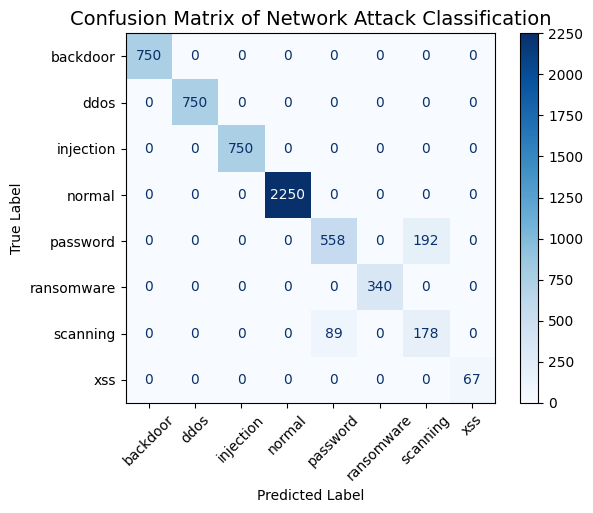


Classification Report:

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00       750
        ddos       1.00      1.00      1.00       750
   injection       1.00      1.00      1.00       750
      normal       1.00      1.00      1.00      2250
    password       0.86      0.74      0.80       750
  ransomware       1.00      1.00      1.00       340
    scanning       0.48      0.67      0.56       267
         xss       1.00      1.00      1.00        67

    accuracy                           0.95      5924
   macro avg       0.92      0.93      0.92      5924
weighted avg       0.96      0.95      0.95      5924



In [271]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Predict on test set
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix with class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# Plot as heatmap
plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', xticks_rotation=45, values_format='d', colorbar=True)
plt.title("Confusion Matrix of Network Attack Classification", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()

# Optionally print detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


In [274]:
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

def predict_attack_type(new_data):
    """
    Predicts the network attack type for new data.

    Args:
        new_data (dict): A dictionary containing the new data with keys:
                         'motion_status', 'light_status', 'hour',
                         'day', 'month', 'weekday'.

    Returns:
        str: The predicted network attack type.
    """
    # Load the scaler and model
    scaler = joblib.load('scaler.pkl')
    model = tf.keras.models.load_model('final_network_model.h5')
    le = joblib.load('type_encoder.pkl')


    # Create a DataFrame from the new data
    new_df = pd.DataFrame([new_data])

    # Preprocess the new data
    # Scale numerical features - Assuming motion_status, light_status, hour, day, month, weekday need scaling.
    features = ['motion_status', 'light_status', 'hour', 'day', 'month', 'weekday']
    new_data_scaled = scaler.transform(new_df[features])


    # Make prediction
    prediction_probs = model.predict(new_data_scaled)
    predicted_class_index = np.argmax(prediction_probs, axis=1)[0]

    # Decode the predicted class
    predicted_attack_type = le.inverse_transform([predicted_class_index])[0]

    return predicted_attack_type

# Example usage:
new_sample = {'motion_status': 1, 'light_status': 1, 'hour': 13, 'day': 28, 'month': 4, 'weekday': 6}
predicted_type = predict_attack_type(new_sample)
print(f"The predicted attack type is: {predicted_type}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
The predicted attack type is: backdoor


In [273]:
df[df['type']==0]

,motion_status,light_status,label,type,hour,day,month,weekday
873,1,1,1,0,13,28,4,6
874,0,0,1,0,13,28,4,6
875,0,0,1,0,13,28,4,6
876,1,1,1,0,13,28,4,6
877,0,0,1,0,13,28,4,6
...,...,...,...,...,...,...,...,...
5868,1,1,1,0,21,28,4,6
5869,0,0,1,0,21,28,4,6
5870,0,0,1,0,21,28,4,6
5871,1,1,1,0,21,28,4,6


In [275]:
df['type'].value_counts()

,count
type,
3,15000
1,5000
0,5000
2,5000
4,5000
5,2264
6,1775
7,449


In [126]:

# type
# normal	15000
# ddos	5000
# backdoor	5000
# injection	5000
# password	5000
# ransomware	2264
# scanning	1775
# xss	449





np.int64(0)